In [1]:
from effects_model_function import *
from functions import *

In [ ]:
# from external EDA
DATA_DIR = "data/EDA/"
# external = pd.read_excel(r"C:\Users\Dizzzy\Downloads\cap-data-download\Book1.xlsx", sheet_name='external_drivers')
external = pd.read_excel(f"{DATA_DIR}external_drivers.xlsx", sheet_name='Sheet1')
emissions = pd.read_excel(f"{DATA_DIR}Emissions_and_Steel_production_per_company_and_year.xlsx", sheet_name= 'Master_Dataset')
company_info = pd.read_excel(f"{DATA_DIR}Emissions_and_Steel_production_per_company_and_year.xlsx", sheet_name= 'Company_Profiles')
fix_column_names(emissions)
fix_column_names(company_info)
fix_column_names(external)
columns_emission = ['company', 'country', 'technology', 'year',
       'production', 'scope1', 'scope2_location', 'scope2_market',
       'scope_1_2_location', 'intensity_location_co2e',
       'intensity_market_co2e']
df_company = pd.merge(emissions[columns_emission],company_info[['company','country','founding_year']],on='company', how='left',suffixes=['','_y'])
df_company.drop(df_company.filter(regex='_y$').columns, axis=1, inplace=True)
df_company.head()

categorical_external_columns = ['cbam', 'ied_update', 'green_deal', 'nzia', 'csp_funding', 'gpp', 'csr',
       'paris', 'ksg', 'esrs', 'glasgow', 'govt_change','eu_parl', 'eu_comm']
external[categorical_external_columns] = external[categorical_external_columns].fillna(0)
# external = external.drop('met_coke_price', axis=1)
external['green_deal'] = external['green_deal'] .replace({'communicated':1})
df = pd.merge(df_company,external, on=['country', 'year'], how='left')
df = df.drop(df[df['company'] == 'ArcelorMittal Europe'].index)
# Set Threshold
df_filtered_scope1 = df.groupby('company').filter(lambda x: x['scope1'].notna().sum() >= 3)
# for now on minimum -> 3
df_scope1 = df_filtered_scope1.dropna(subset=['scope1']).copy() #dropped 3 rows here

df_scope1['intensity1'] = df_scope1['scope1'] / df_scope1['production']
df_scope1.groupby('company').count()
df_scope1.drop(['scope2_location', 'scope2_market', 'scope_1_2_location', 'intensity_location_co2e', 'intensity_market_co2e'], axis = 1, inplace=True)
df_scope1.head(2)

C:\Users\Dizzzy\AppData\Local\Temp\ipykernel_26380\3766527435.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  external['green_deal'] = external['green_deal'] .replace({'communicated':1})


,company,country,technology,year,production,scope1,founding_year,carbon_price,electricity_price,electricity_price_eu,...,govt_change_nl,govt_change_es,govt_change_fi,govt_change_fr,govt_change_lu,govt_change_gb,govt_change_at,eu_parl,eu_comm,intensity1
0,ArcelorMittal,Luxembourg,BF-BOF,2013,90.9,162.0,2007.0,4.3,0.0992,0.1180,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,0.0,0.0,1.782178
1,ArcelorMittal,Luxembourg,BF-BOF,2014,93.4,167.0,2007.0,5.9,0.0997,0.1198,...,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.788009


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112 entries, 0 to 118
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   company                    112 non-null    object 
 1   country                    112 non-null    object 
 2   technology                 112 non-null    object 
 3   year                       112 non-null    int64  
 4   production                 108 non-null    float64
 5   scope1                     81 non-null     float64
 6   scope2_location            72 non-null     float64
 7   scope2_market              32 non-null     float64
 8   scope_1_2_location         67 non-null     float64
 9   intensity_location_co2e    68 non-null     float64
 10  intensity_market_co2e      32 non-null     float64
 11  founding_year              59 non-null     float64
 12  carbon_price               112 non-null    float64
 13  electricity_price          112 non-null    float64
 14 

In [4]:
company_profile_cols = ['company', 'country', 'technology', 'year', 'production', 'scope1',
       'scope2_location', 'scope2_market', 'scope_1_2_location', 'founding_year']
intensity_cols = ['intensity_1','intensity_location_co2e', 'intensity_market_co2e']
prices_cols = ['carbon_price', 'electricity_price', 'electricity_price_eu',
       'coal_price_australia', 'iron_ore_price', 'natural_gas_price',
       'natural_gas_price_eu',]
volumn_cols = ['crude_steel_production','hydrogen_use','sci']
               
ets_cols = ['ets_coke_production','ets_metal_ore', 'ets_iron_steel', 'ets_hydrogen_gas', 'ets']
            
policies_cols = ['cbam', 'ied_update', 'green_deal', 'nzia',
       'csp_funding', 'gpp', 'csr', 'paris', 'ksg', 'esrs', 'glasgow',
       'govt_change', 'eu_parl', 'eu_comm']

df['intensity_1'] = df_scope1['scope1'] / df_scope1['production']

In [5]:
df.to_csv('data/external_drivers_dataframe.csv')

In [6]:
df_scope1.groupby('company').count()

,country,technology,year,production,scope1,founding_year,carbon_price,electricity_price,electricity_price_eu,coal_price_australia,...,govt_change_nl,govt_change_es,govt_change_fi,govt_change_fr,govt_change_lu,govt_change_gb,govt_change_at,eu_parl,eu_comm,intensity1
company,,,,,,,,,,,,,,,,,,,,,
Acciaierie d’Italia Holding,4,4,4,4,4,0,4,4,4,4,...,1,1,1,2,0,2,3,4,4,4
ArcelorMittal,12,12,12,12,12,12,12,12,12,12,...,3,3,4,6,3,5,6,12,12,12
Celsa Group,5,5,5,5,5,5,5,5,5,5,...,2,2,1,3,1,2,2,5,5,5
Dillinger/SHS Group,3,3,3,0,3,0,3,3,3,3,...,0,0,0,0,0,0,0,3,3,0
Outokumpu,12,12,12,12,12,12,12,12,12,12,...,3,3,4,6,3,5,6,12,12,12
SIDENOR Group,6,6,6,5,6,0,6,6,6,6,...,0,0,0,0,0,0,0,6,6,5
SSAB,12,12,12,12,12,12,12,12,12,12,...,3,3,4,6,3,5,6,12,12,12
Salzgitter AG,9,9,9,9,9,9,9,9,9,9,...,3,3,2,5,2,4,5,9,9,9
Tata Steel Nederland,6,6,6,6,6,6,6,6,6,6,...,2,2,2,3,1,3,3,6,6,6


In [7]:
cols = ['country', 'technology', 'production', 'scope1',
       'founding_year', 'carbon_price', 'electricity_price',
       'electricity_price_eu', 'coal_price_australia', 'iron_ore_price',
       'natural_gas_price', 'natural_gas_price_eu', 'crude_steel_production',
       'ets_coke_production', 'ets_metal_ore', 'ets_iron_steel',
       'ets_hydrogen_gas', 'sci', 'hydrogen_use', 'ets', 'cbam', 'ied_update',
       'green_deal', 'nzia', 'csp_funding', 'gpp', 'csr', 'paris', 'ksg',
       'esrs', 'glasgow', 'govt_change', 'eu_parl', 'eu_comm']

cols_enc = ['production', 'scope1', 'founding_year', 'carbon_price',
       'electricity_price', 'electricity_price_eu', 'coal_price_australia',
       'iron_ore_price', 'natural_gas_price', 'natural_gas_price_eu',
       'crude_steel_production', 'ets_coke_production', 'ets_metal_ore',
       'ets_iron_steel', 'ets_hydrogen_gas', 'sci', 'hydrogen_use', 'ets',
       'cbam', 'ied_update', 'green_deal', 'nzia', 'csp_funding', 'gpp', 'csr',
       'paris', 'ksg', 'esrs', 'glasgow', 'govt_change', 'eu_parl', 'eu_comm', 'country_austria',
       'country_finland', 'country_germany', 'country_italy',
       'country_luxembourg', 'country_netherlands', 'country_spain',
       'country_sweden', 'country_uk', 'technology_bf_bof', 'technology_eaf',
       'technology_eaf_stainless']

df = pd.concat([df_scope1['company'], pd.get_dummies(df_scope1.drop(columns=['company']))], axis=1)
fix_column_names(df)
df.columns

Index(['company', 'year', 'production', 'scope1', 'founding_year',
       'carbon_price', 'electricity_price', 'electricity_price_eu',
       'coal_price_australia', 'iron_ore_price', 'natural_gas_price',
       'natural_gas_price_eu', 'crude_steel_production',
       'crude_steel_production_eu', 'ets_coke_production', 'ets_metal_ore',
       'ets_iron_steel', 'ets_hydrogen_gas', 'sci', 'hydrogen_use', 'ets',
       'cbam', 'ied_update', 'green_deal', 'nzia', 'csp_funding', 'gpp', 'csr',
       'paris', 'ksg', 'esrs', 'glasgow', 'govt_change', 'govt_change_de',
       'govt_change_it', 'govt_change_se', 'govt_change_nl', 'govt_change_es',
       'govt_change_fi', 'govt_change_fr', 'govt_change_lu', 'govt_change_gb',
       'govt_change_at', 'eu_parl', 'eu_comm', 'intensity1', 'country_austria',
       'country_europe_multi_country', 'country_finland', 'country_germany',
       'country_italy', 'country_luxembourg', 'country_netherlands',
       'country_spain', 'country_sweden', 'count

In [8]:
# companies with 12 obs
companies = ['ArcelorMittal', 'Outokumpu', 'SSAB']
df = df[df['company'].isin(companies)].copy()
df.head()

,company,year,production,scope1,founding_year,carbon_price,electricity_price,electricity_price_eu,coal_price_australia,iron_ore_price,...,country_italy,country_luxembourg,country_netherlands,country_spain,country_sweden,country_uk,technology_bf_bof,technology_bf_bof_eaf,technology_eaf,technology_eaf_stainless
0,ArcelorMittal,2013,90.9,162.0,2007.0,4.3,0.09920,0.11800,0.007407,92.871959,...,False,True,False,False,False,False,True,False,False,False
1,ArcelorMittal,2014,93.4,167.0,2007.0,5.9,0.09970,0.11980,0.006226,67.423384,...,False,True,False,False,False,False,True,False,False,False
2,ArcelorMittal,2015,92.7,168.0,2007.0,7.6,0.09105,0.11580,0.006929,51.436968,...,False,True,False,False,False,False,True,False,False,False
3,ArcelorMittal,2016,90.4,167.0,2007.0,5.2,0.08655,0.11220,0.008110,56.131439,...,False,True,False,False,False,False,True,False,False,False
4,ArcelorMittal,2017,92.9,170.0,2007.0,5.8,0.07915,0.11275,0.010277,65.261844,...,False,True,False,False,False,False,True,False,False,False


In [9]:
x_vars_clean = [
    'ets_iron_steel', 'ets', 'production', 'scope1', 
    'crude_steel_production', 'electricity_price',
    'coal_price_australia', 'iron_ore_price', 
    'natural_gas_price', 'govt_change'  # Remove problematic ones
]
formula = " + ".join(x_vars_clean)
formula

'ets_iron_steel + ets + production + scope1 + crude_steel_production + electricity_price + coal_price_australia + iron_ore_price + natural_gas_price + govt_change'

In [10]:
from statsmodels.regression.mixed_linear_model import MixedLM

import statsmodels.api as sm

import statsmodels.formula.api as smf


md = smf.mixedlm(f"intensity1 ~ year + {formula}", df, groups=df["company"])

mdf = md.fit()

print(mdf.summary())


              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    intensity1
No. Observations:    36         Method:                REML      
No. Groups:          3          Scale:                 0.0007    
Min. group size:     12         Log-Likelihood:        22.3665   
Max. group size:     12         Converged:             Yes       
Mean group size:     12.0                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               6.627    4.788  1.384 0.166 -2.756 16.010
year                   -0.003    0.002 -1.141 0.254 -0.007  0.002
ets_iron_steel          0.000    0.000  0.982 0.326 -0.000  0.000
ets                    -0.001    0.026 -0.048 0.962 -0.053  0.050
production             -0.027    0.008 -3.589 0.000 -0.042 -0.012
scope1                  

In [11]:
comp_specific =['company' 'production', 'scope1', 'founding_year', 'country_austria',
       'country_europe_multi_country', 'country_finland', 'country_germany',
       'country_italy', 'country_luxembourg', 'country_netherlands',
       'country_spain', 'country_sweden', 'country_uk', 'technology_bf_bof',
       'technology_eaf', 'technology_eaf_scrap_recycling',
       'technology_eaf_stainless']
rand = ['carbon_price', 'electricity_price', 'electricity_price_eu',
       'coal_price_australia', 'iron_ore_price', 'natural_gas_price',
       'natural_gas_price_eu', 'crude_steel_production', 'ets_coke_production',
       'ets_metal_ore', 'ets_iron_steel', 'ets_hydrogen_gas', 'sci',
       'hydrogen_use', 'ets', 'cbam', 'ied_update', 'green_deal', 'nzia',
       'csp_funding', 'gpp', 'csr', 'paris', 'ksg', 'esrs', 'glasgow',
       'govt_change', 'eu_parl', 'eu_comm']

x_vars_clean = [
    'ets_iron_steel', 'ets', 'production', 'scope1', 
    'crude_steel_production', 'electricity_price',
    'coal_price_australia', 'iron_ore_price', 
    'natural_gas_price', 'govt_change'  # Remove problematic ones
]
from mixed_effects_model import *
# Random intercept model
result1 = MixedEffectsModel(
    df, 
    y='intensity1', 
    x_vars=x_vars_clean
)
print("Random Intercept Model:")
print(result1.summary())

# Random intercept + random slope for price
result2 = MixedEffectsModel(
    df, 
    y='intensity1', 
    x_vars=x_vars_clean,
    random_effects=x_vars_clean
)
print("\n\nRandom Intercept + Random Slope Model:")
print(result2.summary())

Random Intercept Model:
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    intensity1
No. Observations:    36         Method:                REML      
No. Groups:          3          Scale:                 0.0007    
Min. group size:     12         Log-Likelihood:        26.8435   
Max. group size:     12         Converged:             Yes       
Mean group size:     12.0                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               1.190    0.436  2.730 0.006  0.336  2.044
ets_iron_steel          0.000    0.000  0.745 0.457 -0.000  0.000
ets                    -0.012    0.025 -0.497 0.619 -0.060  0.036
production             -0.025    0.007 -3.405 0.001 -0.040 -0.011
scope1                  0.014    0.004  3.209 0.001  0.005  0.022


e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)




Random Intercept + Random Slope Model:
                            Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             intensity1
No. Observations:              36                  Method:                         REML      
No. Groups:                    3                   Scale:                          0.0010    
Min. group size:               12                  Log-Likelihood:                 -10.3429  
Max. group size:               12                  Converged:                      Yes       
Mean group size:               12.0                                                          
---------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                      

e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [12]:
compare_panel_models(df,y='intensity1',x_vars=x_vars_clean)

Fixed Effects failed: 
The model cannot be estimated. The included effects have fully absorbed
one or more of the variables. This occurs when one or more of the dependent
variable is perfectly explained using the effects included in the model.

The following variables or variable combinations have been fully absorbed
or have become perfectly collinear after effects are removed:

          ets, production, scope1, crude_steel_production, electricity_price, coal_price_australia, natural_gas_price, govt_change
          coal_price_australia, iron_ore_price
          ets, coal_price_australia, iron_ore_price

Set drop_absorbed=True to automatically drop absorbed variables.



{'random':                         RandomEffects Estimation Summary                        
 Dep. Variable:             intensity1   R-squared:                        0.9686
 Estimator:              RandomEffects   R-squared (Between):              0.9854
 No. Observations:                  36   R-squared (Within):              -36.476
 Date:                Thu, Dec 04 2025   R-squared (Overall):              0.9686
 Time:                        15:06:28   Log-likelihood                    0.2648
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      80.154
 Entities:                           3   P-value                           0.0000
 Avg Obs:                       12.000   Distribution:                   F(10,26)
 Min Obs:                       12.000                                           
 Max Obs:                       12.000   F-statistic (robust):           -3.7e+13
      

In [13]:
prices = ['carbon_price', 'electricity_price', 'electricity_price_eu',
          'coal_price_australia', 'iron_ore_price', 'natural_gas_price','natural_gas_price_eu'
    ]
volume = ['production', 'scope1', 'crude_steel_production'
    ]
ets = ['ets_coke_production','ets_metal_ore', 'ets_iron_steel', 'ets_hydrogen_gas', 'ets_coke_production', 'ets'
    ]
ets1 = ['ets_iron_steel', 'ets']
policies = ['govt_change', 'green_deal', 'csp_funding']

# 'company', 'year' 'founding_year','sci','hydrogen_use', 'cbam', 'ied_update',  'nzia','gpp', 'csr', 'paris', 'ksg', 'esrs', 'glasgow', 'eu_parl', 'eu_comm', 

countries_enc = ['country_austria','country_finland', 'country_germany', 'country_italy','country_luxembourg', 
                 'country_netherlands', 'country_spain','country_sweden', 'country_uk'
    ]
technologies = ['technology_bf_bof', 'technology_eaf', 'technology_eaf_stainless']

In [14]:
# x_vars = ['electricity_price', 'natural_gas_price', 'crude_steel_production']


fe_result = EffectsModel(df,y='intensity1', x_vars= ets1 +volume+ prices+policies, threshold_obs=12)
fe_result

e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


Dep. Variable:,intensity1,R-squared:,0.5478
Estimator:,PanelOLS,R-squared (Between):,-0.1298
No. Observations:,36,R-squared (Within):,0.5478
Date:,"Thu, Dec 04 2025",R-squared (Overall):,-0.1280
Time:,15:06:29,Log-likelihood,91.064
Cov. Estimator:,Clustered,,
,,F-statistic:,1.6443
Entities:,3,P-value,0.1548
Avg Obs:,12.000,Distribution:,"F(14,19)"
Min Obs:,12.000,,
Max Obs:,12.000,F-statistic (robust):,1.265e+05


In [15]:
EffectsModel(df,y='intensity1', x_vars= ets1 +volume+ prices+policies, threshold_obs=12)

e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


Dep. Variable:,intensity1,R-squared:,0.5478
Estimator:,PanelOLS,R-squared (Between):,-0.1298
No. Observations:,36,R-squared (Within):,0.5478
Date:,"Thu, Dec 04 2025",R-squared (Overall):,-0.1280
Time:,15:06:29,Log-likelihood,91.064
Cov. Estimator:,Clustered,,
,,F-statistic:,1.6443
Entities:,3,P-value,0.1548
Avg Obs:,12.000,Distribution:,"F(14,19)"
Min Obs:,12.000,,
Max Obs:,12.000,F-statistic (robust):,1.265e+05


In [16]:
EffectsModel(df,y='intensity1', x_vars= ets1 +volume+ prices+policies, threshold_obs=12, auto_drop_invariant=False)

e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


Dep. Variable:,intensity1,R-squared:,0.5478
Estimator:,PanelOLS,R-squared (Between):,-0.1298
No. Observations:,36,R-squared (Within):,0.5478
Date:,"Thu, Dec 04 2025",R-squared (Overall):,-0.1280
Time:,15:06:29,Log-likelihood,91.064
Cov. Estimator:,Clustered,,
,,F-statistic:,1.6443
Entities:,3,P-value,0.1548
Avg Obs:,12.000,Distribution:,"F(14,19)"
Min Obs:,12.000,,
Max Obs:,12.000,F-statistic (robust):,1.265e+05


In [17]:
# 1. REMOVE PERFECTLY COLLINEAR VARIABLES - i dont remember when or how this happpened tbh
x_vars_clean = [
    'ets_iron_steel', 'ets', 'production', 'scope1', 
    'crude_steel_production', 'electricity_price',
    'coal_price_australia', 'iron_ore_price', 
    'natural_gas_price', 'govt_change'  # Remove problematic ones
]

# 2. RUN CLEAN MODEL
re_result=EffectsModel(df,y='intensity1', x_vars= x_vars_clean, threshold_obs=12, model = 'random')
re_result

e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


Dep. Variable:,intensity1,R-squared:,0.9686
Estimator:,RandomEffects,R-squared (Between):,0.9854
No. Observations:,36,R-squared (Within):,-36.476
Date:,"Thu, Dec 04 2025",R-squared (Overall):,0.9686
Time:,15:06:29,Log-likelihood,0.2648
Cov. Estimator:,Clustered,,
,,F-statistic:,80.154
Entities:,3,P-value,0.0000
Avg Obs:,12.000,Distribution:,"F(10,26)"
Min Obs:,12.000,,
Max Obs:,12.000,F-statistic (robust):,-229.10


In [18]:
# Hausman Test: FE vs RE
from linearmodels.panel import compare
# 1. REMOVE PERFECTLY COLLINEAR VARIABLES - i dont remember when or how this happpened tbh
x_vars_clean = [
    'ets_iron_steel', 'ets',
    'crude_steel_production', 'electricity_price',
    'coal_price_australia', 'iron_ore_price', 
    'natural_gas_price', 'govt_change'  # Remove problematic ones
]
fe_result = EffectsModel(df,y='intensity1', x_vars= x_vars_clean, threshold_obs=12, auto_drop_invariant=False)
re_result=EffectsModel(df,y='intensity1', x_vars= x_vars_clean, threshold_obs=12, model= 'random')
fetw_result =EffectsModel(df,y='intensity1', x_vars= x_vars_clean, threshold_obs=12, model= 'twoway',auto_drop_invariant=False)
# Compare
comparison = compare({'FE': fe_result, 'FE_TW' : fetw_result, 'RE': re_result})
print(comparison.summary)

                             Model Comparison                             
                                       FE          FE_TW                RE
--------------------------------------------------------------------------
Dep. Variable                  intensity1     intensity1        intensity1
Estimator                        PanelOLS       PanelOLS     RandomEffects
No. Observations                       36             36                36
Cov. Est.                       Clustered      Clustered         Clustered
R-squared                          0.1973         0.0738            0.9507
R-Squared (Within)                 0.1973        -0.0974           -66.793
R-Squared (Between)                0.0847         0.0073            0.9811
R-Squared (Overall)                0.0847         0.0073            0.9507
F-statistic                        0.7683         0.3588            67.559
P-value (F-stat)                   0.6335         0.8346            0.0000
======================== 

e:\Bootcamp_DS25\projects\capstone\SusteelAible\effects_model_function.py:109: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

ets, coal_price_australia, iron_ore_price, natural_gas_price

  result = mod.fit(
e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")
e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")
e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")
e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


Coefficient Data:
                                  FE         FE_TW            RE
ets_iron_steel          8.275731e-09  3.316511e-09 -5.027946e-07
ets                    -3.220815e-04           NaN  6.630264e-02
crude_steel_production  1.082236e-02  7.690068e-03  5.800844e-01
electricity_price      -1.681028e-01 -2.863616e-01  8.894312e-01
coal_price_australia    1.601757e+00           NaN -6.432469e+00
iron_ore_price          1.310751e-04           NaN  3.736441e-03
natural_gas_price      -4.452711e-02           NaN  3.507535e+00
govt_change             3.931501e-03  3.478787e-03  1.548171e-02


Plot 1: Side-by-side bar plot


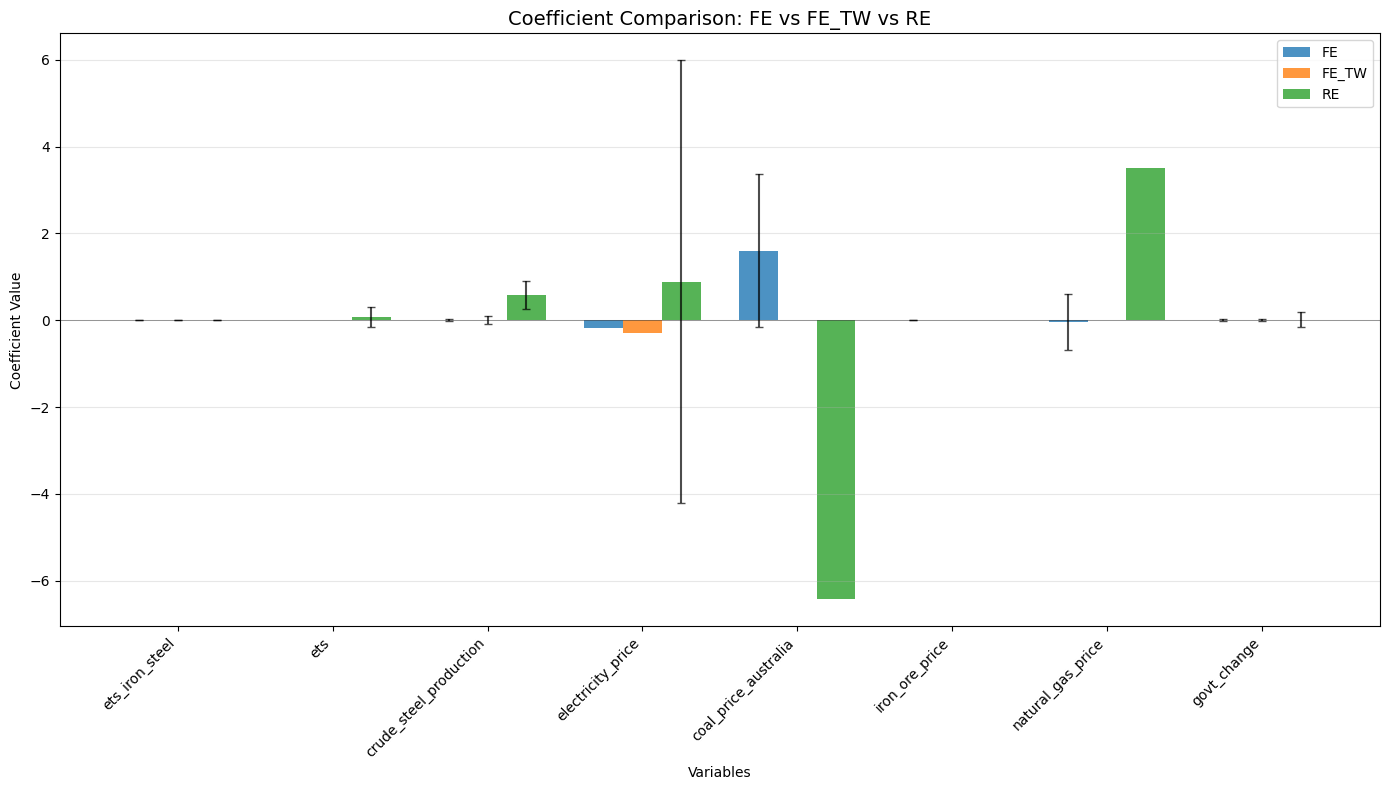

Plot 2: Dot plot with confidence intervals


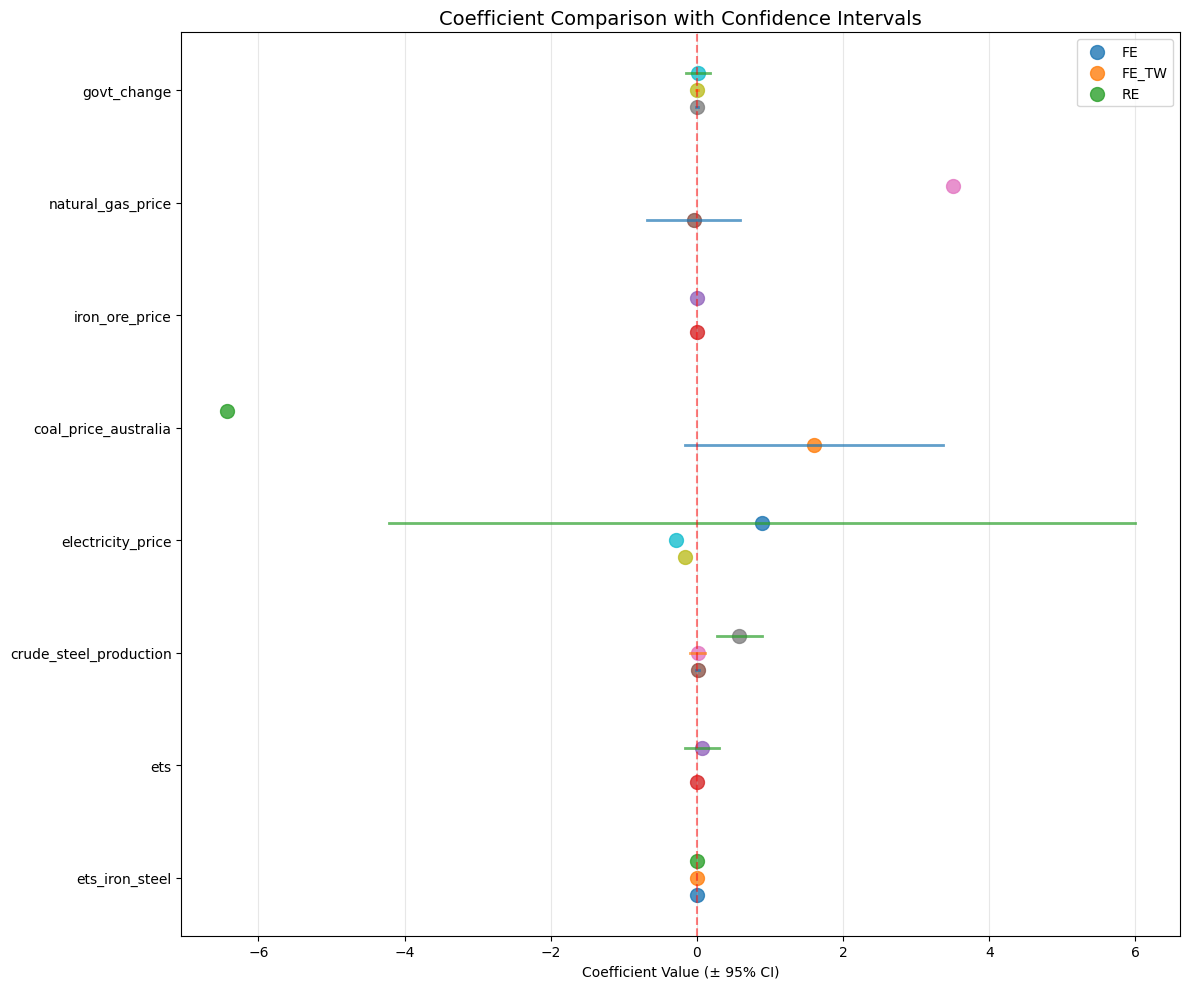

Plot 5: Summary comparison


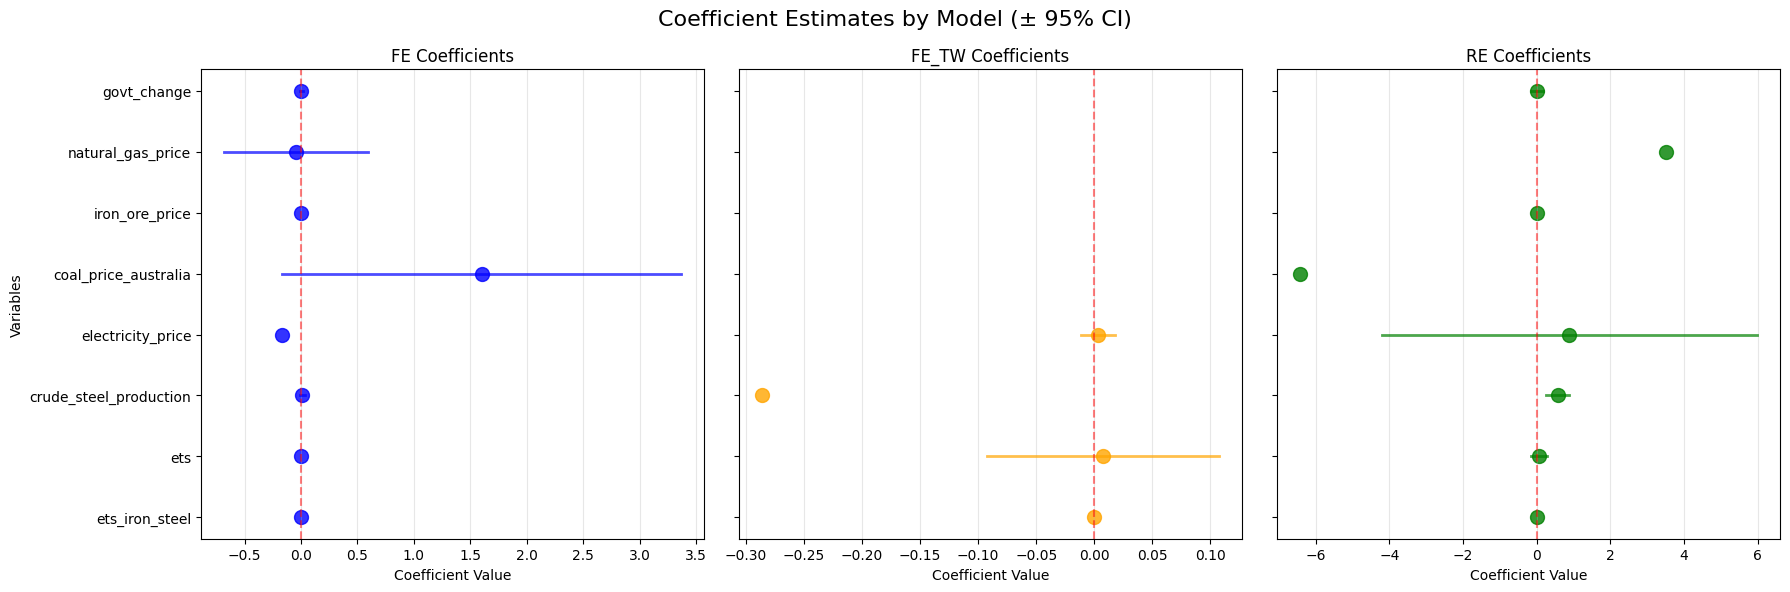


SUMMARY TABLE OF COEFFICIENTS
                          FE_coef   FE_stderr FE_TW_coef FE_TW_stderr  \
ets_iron_steel           0.000000  (0.000000)   0.000000   (0.000000)   
ets                     -0.000322          NA         NA           NA   
crude_steel_production   0.010822  (0.011337)   0.007690   (0.051008)   
electricity_price       -0.168103          NA  -0.286362           NA   
coal_price_australia     1.601757  (0.901895)         NA           NA   
iron_ore_price           0.000131  (0.000205)         NA           NA   
natural_gas_price       -0.044527  (0.325888)         NA           NA   
govt_change              0.003932  (0.007075)   0.003479   (0.007446)   

                          RE_coef   RE_stderr  
ets_iron_steel          -0.000001  (0.000000)  
ets                      0.066303  (0.116871)  
crude_steel_production   0.580084  (0.159273)  
electricity_price        0.889431  (2.601746)  
coal_price_australia    -6.432469          NA  
iron_ore_price         

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fe_coefs = comparison.params['FE']
fe_tw_coefs = comparison.params['FE_TW']
re_coefs = comparison.params['RE']

fe_stderr = comparison.std_errors['FE']
fe_tw_stderr = comparison.std_errors['FE_TW']
re_stderr = comparison.std_errors['RE']

# DataFrames for plotting
coef_df = pd.DataFrame({
    'FE': fe_coefs,
    'FE_TW': fe_tw_coefs,
    'RE': re_coefs
})

stderr_df = pd.DataFrame({
    'FE': fe_stderr,
    'FE_TW': fe_tw_stderr,
    'RE': re_stderr
})

# Drop nan values (some coefficients are missing in some models)
coef_df = coef_df.dropna(how='all')
stderr_df = stderr_df.loc[coef_df.index]

# Method 1: Side-by-side bar plot
def plot_coefficients_side_by_side(coef_df, stderr_df=None):
    """Plot coefficients side by side for each model."""
    plt.figure(figsize=(14, 8))
    
    x = np.arange(len(coef_df))
    width = 0.25
    models = coef_df.columns
    
    for i, model in enumerate(models):
        offset = (i - len(models)/2 + 0.5) * width
        bars = plt.bar(x + offset, coef_df[model], width, 
                      label=model, alpha=0.8)
        
        # Add error bars if available
        if stderr_df is not None and model in stderr_df.columns:
            plt.errorbar(x + offset, coef_df[model], 
                        yerr=stderr_df[model] * 1.96,  # 95% CI
                        fmt='none', color='black', capsize=3, alpha=0.7)
    
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    plt.xlabel('Variables')
    plt.ylabel('Coefficient Value')
    plt.title('Coefficient Comparison: FE vs FE_TW vs RE', fontsize=14)
    plt.xticks(x, coef_df.index, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Method 2: Dot plot with confidence intervals
def plot_coefficients_dot(coef_df, stderr_df=None):
    """Plot coefficients as dots with confidence intervals."""
    plt.figure(figsize=(12, 10))
    
    models = coef_df.columns
    n_models = len(models)
    
    for var_idx, variable in enumerate(coef_df.index):
        y_pos = var_idx
        
        for model_idx, model in enumerate(models):
            if pd.notna(coef_df.loc[variable, model]):
                coef = coef_df.loc[variable, model]
                
                # Plot coefficient point
                plt.scatter(coef, y_pos + (model_idx - n_models/2 + 0.5) * 0.15,
                           s=100, label=model if var_idx == 0 else "",
                           alpha=0.8)
                
                # Plot confidence interval if available
                if (stderr_df is not None and model in stderr_df.columns and 
                    pd.notna(stderr_df.loc[variable, model])):
                    stderr = stderr_df.loc[variable, model]
                    plt.plot([coef - 1.96*stderr, coef + 1.96*stderr], 
                            [y_pos + (model_idx - n_models/2 + 0.5) * 0.15] * 2,
                            color=plt.cm.tab10(model_idx), linewidth=2, alpha=0.7)
    
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    plt.yticks(range(len(coef_df.index)), coef_df.index)
    plt.xlabel('Coefficient Value (± 95% CI)')
    plt.title('Coefficient Comparison with Confidence Intervals', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

# Method 5: Compact summary plot
def plot_coefficients_summary(coef_df, stderr_df=None):
    """Compact summary plot showing all models."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
    models = coef_df.columns
    colors = ['blue', 'orange', 'green']
    
    for ax, (model, color) in zip(axes, zip(models, colors)):
        model_coefs = coef_df[model].dropna()
        
        if not model_coefs.empty:
            y_pos = range(len(model_coefs))
            
            # Plot coefficients
            ax.scatter(model_coefs.values, y_pos, color=color, s=100, 
                      alpha=0.8, label=model)
            
            # Add confidence intervals if available
            if stderr_df is not None and model in stderr_df.columns:
                model_stderr = stderr_df[model].loc[model_coefs.index]
                for i, (coef, err) in enumerate(zip(model_coefs.values, model_stderr.values)):
                    if pd.notna(err):
                        ax.plot([coef - 1.96*err, coef + 1.96*err], 
                               [i, i], color=color, linewidth=2, alpha=0.7)
            
            ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
            ax.set_xlabel('Coefficient Value')
            ax.set_title(f'{model} Coefficients')
            ax.grid(True, alpha=0.3, axis='x')
    
    axes[0].set_yticks(range(len(coef_df)))
    axes[0].set_yticklabels(coef_df.index)
    axes[0].set_ylabel('Variables')
    
    plt.suptitle('Coefficient Estimates by Model (± 95% CI)', fontsize=16)
    plt.tight_layout()
    plt.show()

# Execute the plots
print("Coefficient Data:")
print(coef_df)
print("\n" + "="*80 + "\n")

# Plot 1: Side-by-side bars
print("Plot 1: Side-by-side bar plot")
plot_coefficients_side_by_side(coef_df, stderr_df)

# Plot 2: Dot plot with confidence intervals
print("Plot 2: Dot plot with confidence intervals")
plot_coefficients_dot(coef_df, stderr_df)


# Plot 5: Summary
print("Plot 5: Summary comparison")
plot_coefficients_summary(coef_df, stderr_df)

# Additional: Create a summary table
print("\n" + "="*80)
print("SUMMARY TABLE OF COEFFICIENTS")
print("="*80)

# Create a formatted summary table
summary_table = pd.DataFrame()
for model in coef_df.columns:
    summary_table[f'{model}_coef'] = coef_df[model].apply(lambda x: f'{x:.6f}' if pd.notna(x) else 'NA')
    if stderr_df is not None and model in stderr_df.columns:
        summary_table[f'{model}_stderr'] = stderr_df[model].apply(lambda x: f'({x:.6f})' if pd.notna(x) else 'NA')

print(summary_table)

# Save coefficients to CSV
coef_df.to_csv('coefficient_comparison.csv')
print("\nCoefficients saved to 'coefficient_comparison.csv'")

In [20]:
# Calculate VIF for remaining variables
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vars = ['ets_iron_steel', 'ets', 'crude_steel_production', 
          'electricity_price', 'coal_price_australia', 
          'iron_ore_price', 'natural_gas_price', 'govt_change']

vif_data = []
for i, var in enumerate(X_vars):
    vif = variance_inflation_factor(df[X_vars].values, i)
    vif_data.append({'variable': var, 'VIF': vif})

vif_data

[{'variable': 'ets_iron_steel', 'VIF': 26.494016454509154},
 {'variable': 'ets', 'VIF': 117.79032739489294},
 {'variable': 'crude_steel_production', 'VIF': 53.66486809379396},
 {'variable': 'electricity_price', 'VIF': 22.55336147101455},
 {'variable': 'coal_price_australia', 'VIF': 18.275986083868997},
 {'variable': 'iron_ore_price', 'VIF': 31.389619099818212},
 {'variable': 'natural_gas_price', 'VIF': 38.876260285788454},
 {'variable': 'govt_change', 'VIF': 1.607408765269989}]

In [21]:
fe_result = EffectsModel(df_scope1,y='intensity1', x_vars= x_vars_clean, threshold_obs=12, auto_drop_invariant=False)
re_result=EffectsModel(df_scope1,y='intensity1', x_vars= x_vars_clean, threshold_obs=12, entity='country', model = 'random')
fetw_result =EffectsModel(df_scope1,y='intensity1', x_vars= x_vars_clean, threshold_obs=12,model = 'fixed', auto_drop_invariant=False)
# Compare
comparison = compare({'FE': fe_result, 'FE_TW' : fetw_result, 'RE': re_result})
print(comparison.summary)

                             Model Comparison                             
                                       FE          FE_TW                RE
--------------------------------------------------------------------------
Dep. Variable                  intensity1     intensity1        intensity1
Estimator                        PanelOLS       PanelOLS     RandomEffects
No. Observations                       36             36                36
Cov. Est.                       Clustered      Clustered         Clustered
R-squared                          0.1973         0.1973            0.9507
R-Squared (Within)                 0.1973         0.1973           -66.793
R-Squared (Between)                0.0847         0.0847            0.9811
R-Squared (Overall)                0.0847         0.0847            0.9507
F-statistic                        0.7683         0.7683            67.559
P-value (F-stat)                   0.6335         0.6335            0.0000
======================== 

e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


In [22]:
EffectsModel(df,y='intensity1', x_vars= ets1 +volume+ prices+policies, threshold_obs=12, auto_drop_invariant=False)

e:\Bootcamp_DS25\projects\capstone\SusteelAible\.venv\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


Dep. Variable:,intensity1,R-squared:,0.5478
Estimator:,PanelOLS,R-squared (Between):,-0.1298
No. Observations:,36,R-squared (Within):,0.5478
Date:,"Thu, Dec 04 2025",R-squared (Overall):,-0.1280
Time:,15:06:32,Log-likelihood,91.064
Cov. Estimator:,Clustered,,
,,F-statistic:,1.6443
Entities:,3,P-value,0.1548
Avg Obs:,12.000,Distribution:,"F(14,19)"
Min Obs:,12.000,,
Max Obs:,12.000,F-statistic (robust):,1.265e+05
